# 0. Load parameters


In [1]:
%matplotlib qt

In [2]:
# | tags: [parameters]
subject_id = "101"

In [3]:
from pathlib import Path
import os
import mne
import matplotlib.pyplot as plt
import numpy as np
import mne
from mne.preprocessing import annotate_amplitude
from spectral.preproc import (
    load_data,
    zapline_clean,
    apply_pyprep,
)
from spectral.utils import ProjectPaths, print_timestamp, load_config

# mne.viz.set_browser_backend("matplotlib")
# mne.viz.set_browser_backend("qt")
mne.set_config("MNE_BROWSER_THEME", "light")

# Initialize paths for your subject
paths = ProjectPaths(subject_id)

# Create all directories
paths.create_directories()

# Print paths to verify
print_timestamp("Setting up project paths")
paths.show()

Created directories for sub-101
Project root: /Users/daniel/PhD/Projects/psd-paths
Setting up project paths: 2025-11-25 19:54:29
────────────────────────────────────────────────────────────
Paths for sub-101
Project Root: /Users/daniel/PhD/Projects/psd-paths
────────────────────────────────────────────────────────────
  analysis     : /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-101/analysis
  data         : /Users/daniel/PhD/Projects/psd-paths/data/bids/sub-101
  epochs       : /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-101/epochs
  figures      : /Users/daniel/PhD/Projects/psd-paths/outputs/figures/sub-101
  ica          : /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-101/analysis/ica
  logs         : /Users/daniel/PhD/Projects/psd-paths/data/logs
  outputs      : /Users/daniel/PhD/Projects/psd-paths/outputs
  preprocessed : /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-101/preprocessed
  processing   : /Users/daniel/PhD/Project

This file contains preprocessing files after downsampling them.


# 1. Preprocess raw data


## Note on Configuration Changes

**Important:** When you modify `settings.toml`, Python caches the imported modules and won't automatically see your changes. To apply configuration updates:

1. **Best approach**: Restart the kernel (Kernel → Restart Kernel), then rerun all cells
2. **Quick approach**: Run the reload cell above, then recreate your `ProjectPaths` and `config` objects
3. **Alternative**: The `load_config()` function always reads from disk, so calling it again will get fresh values

The `load_config()` function itself always reads the file from disk, so it will get updated values. However, if modules are cached or objects already created with old config, you need to recreate them.

### EEG Data Analysis

_EEG were first physically referenced to Cz (VREF) during recording_

EEG data were analysed using **MNE-Python** (Gramfort et al., 2013; version 1.7). 

_Bad fragments of data were identified using pyriemann package and annotated as bad._


Data were originally recorded at 1000 Hz and resampled to **250 Hz** during analysis. 



We dropped some channels to avoid artefacts.
To eliminate line power noise, a **50 Hz notch filter** was applied, followed by a **1-40 Hz bandpass FIR filter**.

Bad channels were identified using the Python implementation of the **Preprocessing Pipeline (PREP)** (Bigdely-Shamlo et al., 2015). These channels were temporarily excluded and later interpolated after Independent Component Analysis (ICA). The dataset was epoched into **5-second intervals** with a **3-second overlap** (1.5s padding on each side). The **Autoreject** library (Jas et al., 2017) was used to detect and annotate fragment excessive artifacts; epochs identified as bad on more than 40% of channels were marked as bad.

 **ICA** was performed using the **PICARD** method (`ortho=False`, `extended=True`), aligning with the FastICA algorithm (Ablin, Cardoso, and Gramfort, 2018). The number of components was determined by capturing **99% of cumulative variance**. Components identified as artifacts (blinks, eye movements, heartbeat, muscular) were visually inspected and removed. Finally, signal from bad channels was reconstructed using **spline interpolation** (head radius 95.5 mm).

# Load data 

In [4]:
config = load_config()

# Access the bad channels list
bad_channels = config["preprocessing"]["channels_to_remove"]
print(f"Channels to remove: {bad_channels}")

raw = load_data(subject_id, data_path=paths.data)

if "Cz" in raw.ch_names:
    if "Cz" not in raw.info["bads"]:
        raw.info["bads"].append("Cz")
        print(f"Marked Cz as bad channel (Reference)")

Channels to remove: ['E67', 'E73', 'E82', 'E91', 'E92', 'E102', 'E111', 'E120', 'E133', 'E145', 'E165', 'E174', 'E187', 'E199', 'E208', 'E209', 'E216', 'E217', 'E218', 'E219', 'E225', 'E226', 'E227', 'E228', 'E229', 'E230', 'E231', 'E232', 'E233', 'E234', 'E235', 'E236', 'E237', 'E238', 'E239', 'E240', 'E241', 'E242', 'E243', 'E244', 'E245', 'E246', 'E247', 'E248', 'E249', 'E250', 'E251', 'E252', 'E253', 'E254', 'E255', 'E256']
Loading BrainVision data from: sub-101_ses-01_task-RESTING_eeg.vhdr
Extracting parameters from /Users/daniel/PhD/Projects/psd-paths/data/bids/sub-101/ses-01/eeg/sub-101_ses-01_task-RESTING_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 300397  =      0.000 ...   300.397 secs...
Loaded 258 channels, 300.4 seconds of data
Identified ECG channels: ['ECG']
Removed 'VREF' channel.
Applying GSN-HydroCel-256 montage...


## Potato

In [5]:
import mne
import numpy as np
from pyriemann.clustering import Potato
from pyriemann.estimation import Covariances


def annotate_with_potato_robust(
    raw,
    l_freq=0.5,
    h_freq=None,
    start_threshold=2.9,
    window_duration=1.5,
    resample_freq=250,
):
    # 1. CLEAN UP BEFORE STARTING
    raw_clean = raw.copy()
    raw_clean.resample(resample_freq, verbose=False)
    # C. HIGH-PASS FILTER (The requested addition)
    if l_freq is not None:
        print(f"   High-pass filtering > {l_freq} Hz...")
        raw_clean.filter(l_freq=l_freq, h_freq=h_freq, verbose=False)
    if len(raw_clean.info["bads"]) > 0:
        print(
            f"Interpolating {len(raw_clean.info['bads'])} bad channels before Potato..."
        )
        raw_clean.interpolate_bads(reset_bads=True, verbose=False)

    # 2. EPOCH THE DATA (FORCE KEEP)
    events = mne.make_fixed_length_events(raw_clean, duration=window_duration)

    # reject_by_annotation=False forces MNE to ignore existing BAD labels
    epochs = mne.Epochs(
        raw_clean,
        events,
        tmin=0,
        tmax=window_duration,
        baseline=None,
        preload=True,
        verbose=False,
        reject=None,
        flat=None,
        reject_by_annotation=False,
    )

    if len(epochs) == 0:
        print("Error: Epochs are still empty. Check if your data duration > 0.")
        return None

    picks = mne.pick_types(raw_clean.info, eeg=True, ecg=False, eog=False)
    X = epochs.get_data(picks=picks)

    # 3. COMPUTE COVARIANCES
    try:
        covs = Covariances(estimator="lwf").fit_transform(X)
    except ValueError as e:
        print(f"Error computing covariances: {e}. Data might be too corrupt.")
        return None

    # 4. FIT POTATO (With Auto-Scaling Threshold)
    potato = None
    final_threshold = start_threshold

    for try_thresh in [start_threshold, 5, 10, 20, 50, 100]:
        try:
            print(f"Trying Potato with threshold={try_thresh}...")
            temp_potato = Potato(metric="riemann", threshold=try_thresh)
            temp_potato.fit(covs)

            potato = temp_potato
            final_threshold = try_thresh
            print(f"Potato fit successfully with threshold={final_threshold}")
            break
        except ValueError:
            continue

    if potato is None:
        print("Potato failed even at threshold=100. Your data is extremely noisy.")
        return None

    # 5. PREDICT
    labels = potato.predict(covs)  # 1=Clean, 0=Bad
    bad_indices = np.where(labels == 0)[0]

    onsets = []
    durations = []

    if len(bad_indices) > 0:
        epoch_times = events[:, 0] / raw_clean.info["sfreq"]
        for idx in bad_indices:
            onsets.append(epoch_times[idx])
            durations.append(window_duration)

        print(f"Found {len(bad_indices)} bad segments.")

        return mne.Annotations(
            onset=onsets,
            duration=durations,
            description=["BAD_potato"] * len(onsets),
            orig_time=raw.annotations.orig_time,
        )
    else:
        print("No artifacts found.")
        return None


# --- USAGE ---
potato_annots = annotate_with_potato_robust(raw, h_freq=40.0)
raw_potato = raw.copy()
if potato_annots:
    raw_potato.set_annotations(raw_potato.annotations + potato_annots)
    # Use butterfly=True to see the artifacts clearly

   High-pass filtering > 0.5 Hz...
Trying Potato with threshold=2.9...
Potato fit successfully with threshold=2.9
Found 16 bad segments.


## Filtering

Polyphase resampling neighborhood: ±2 input samples
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1651 samples (6.604 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter l

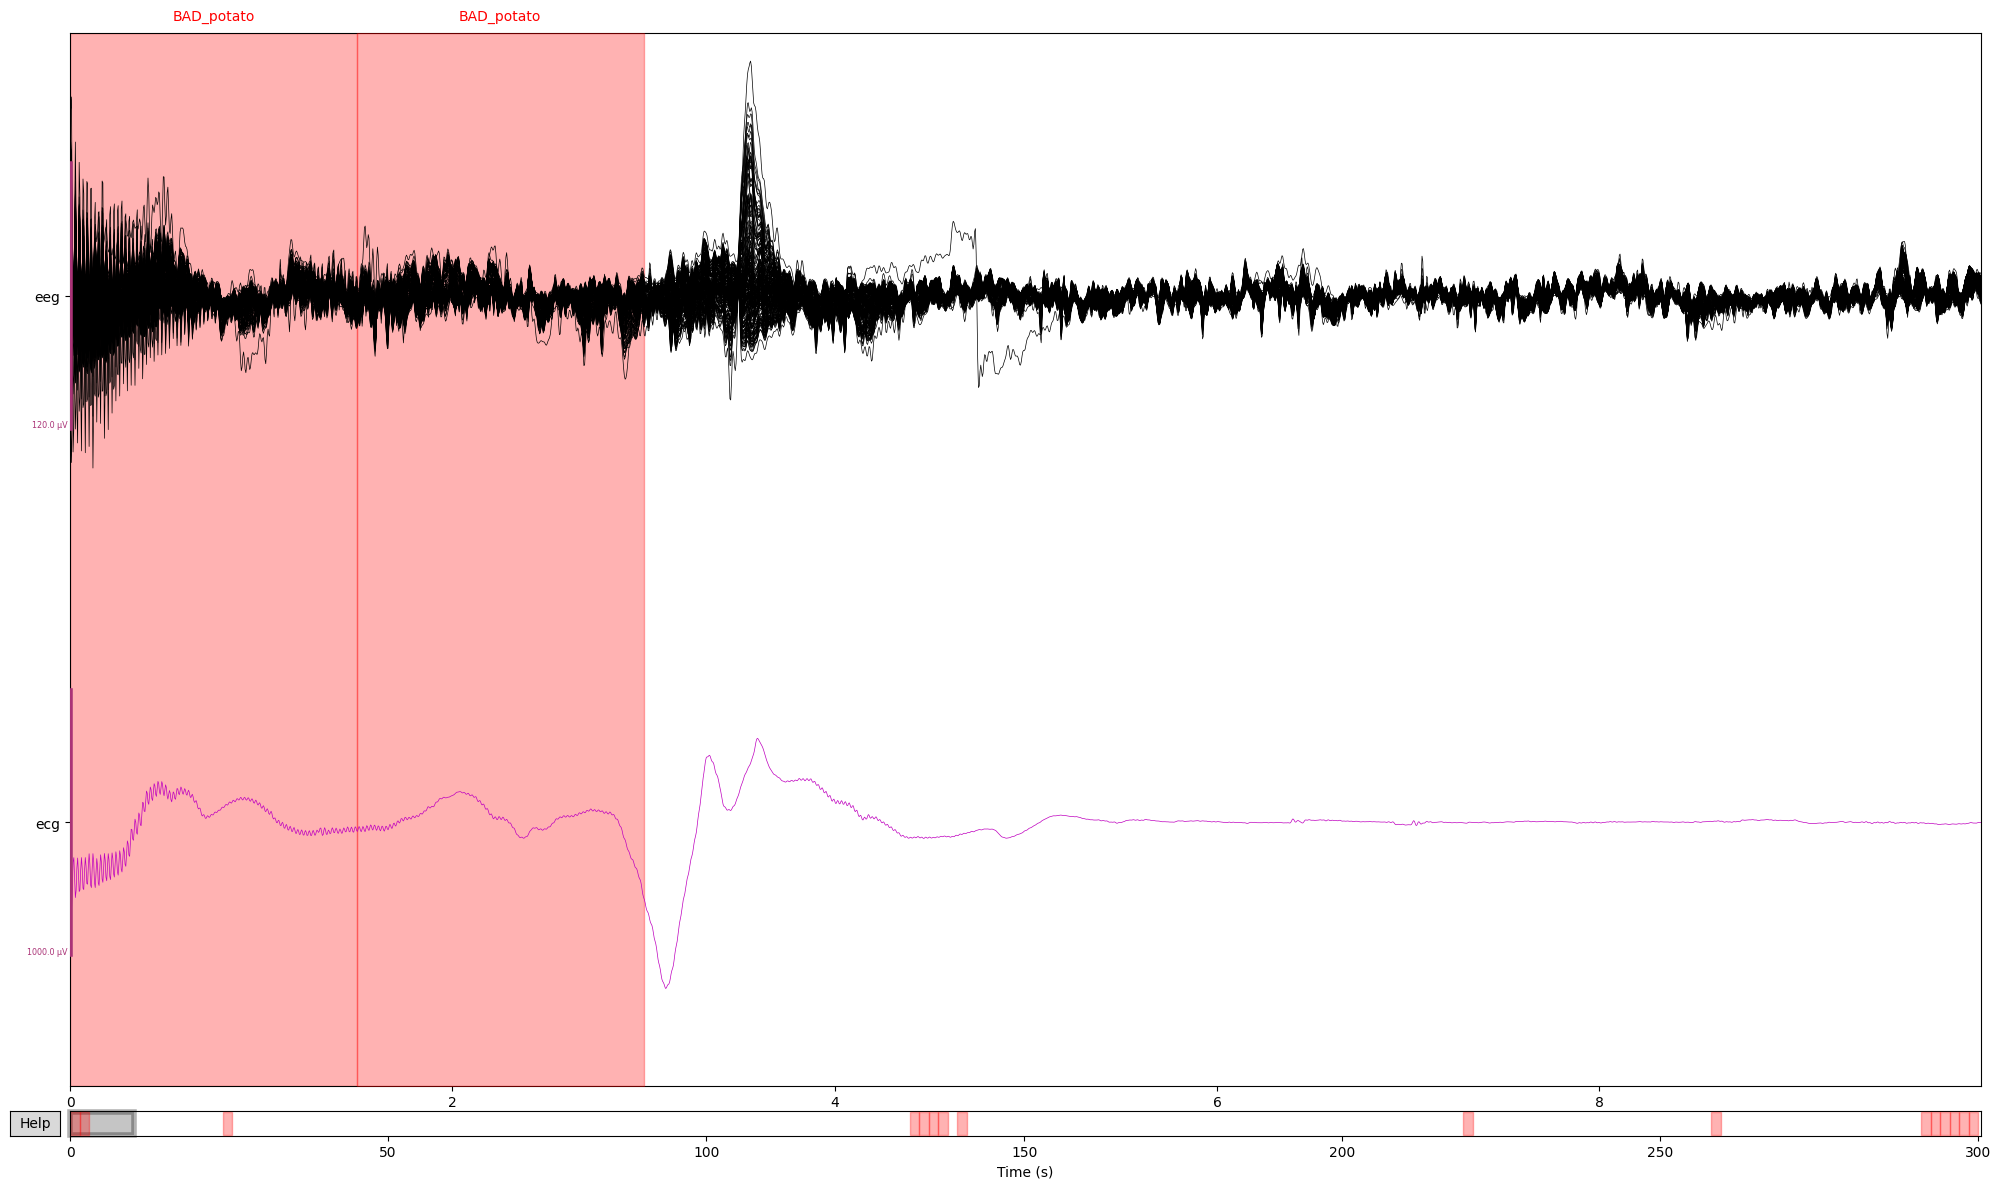

In [26]:
fline = [50, 100]  # Line noise frequencies
h_freq = 45
l_freq = 1
total_duration = raw.times[-1]


filter_params = {
    "l_freq": l_freq,
    "h_freq": h_freq,
    "h_trans_bandwidth": "auto",
    "fir_window": "hamming",
    "fir_design": "firwin",
    "phase": "zero",
    "picks": ["ecg", "eeg"],
}

standard_scalings = {
    "eeg": 60e-6,  # 40 µV (Good for clean brainwaves)
    "ecg": 500e-6,  # 500 µV (ECG is naturally much larger)
    "eog": 150e-6,
}
raw_filtered = (
    raw_potato.copy()
    .resample(250, method="polyphase", verbose=True)
    .drop_channels(bad_channels)
    .notch_filter(freqs=[fline], method="fir", picks=["eeg", "ecg"])
    .filter(**filter_params)
    # .crop(tmin=3.0, tmax=total_duration - 3, include_tmax=True)
)
raw_filtered.copy().plot(scalings=standard_scalings, butterfly=True)

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
raw_psd = (
    raw_filtered.copy()
    .crop(tmin=3.0, tmax=total_duration - 3, include_tmax=True)
    .compute_psd(fmax=60.0, method="welch", picks="eeg", exclude="bads")
    .plot(
        average=False, picks="eeg", exclude="bads", show=False, axes=ax, amplitude=False
    )
)
ax.set_title(f"sub-{subject_id} PSD")

Setting 4600 of 73600 (6.25%) samples to NaN, retaining 69000 (93.75%) samples.
Effective window size : 8.192 (s)
At least one good data span is shorter than n_per_seg, and will be analyzed with a shorter window than the rest of the file.
Plotting power spectral density (dB=True).


/Users/daniel/PhD/Projects/psd-paths/.venv/lib/python3.13/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 375, using nperseg = 375
  return _func(*args, **kwargs)


Text(0.5, 1.0, 'sub-101 PSD')

In [33]:
from spectral.ica import compute_ica

raw_filtered_ica = raw.copy().filter(l_freq=1.0, h_freq=None)
ica = compute_ica(raw_filtered_ica, n_components=0.99, method="picard")


print(ica.n_components_)
if ica.n_components_ > 50:
    ica = compute_ica(epochs_good, n_components=50, method="picard")
ica.save(f"{paths.ica}/sub-{subject_id}_my_ica_model-ica.fif", overwrite=True)
ica_plot_components = ica.plot_components()

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)

Fitting ICA to data using 256 channels (please be patient, this may take a while)
Selecting by explained variance: 4 components
Fitting ICA took 2.8s.
4
Overwriting existing file.
Writing ICA solution to /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-101/analysis/ica/sub-101_my_ica_model-ica.fif...
Overwriting existing file.


In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
raw_psd = (
    raw_potato.copy()
    .crop(tmin=3.0, tmax=total_duration - 3, include_tmax=True)
    .compute_psd(fmax=60.0, method="welch", picks="eeg", exclude="bads")
    .plot(
        average=False, picks="eeg", exclude="bads", show=False, axes=ax, amplitude=False
    )
)
ax.set_title(f"sub-{subject_id} PSD")

Setting 18398 of 294398 (6.25%) samples to NaN, retaining 276000 (93.75%) samples.
Effective window size : 2.048 (s)
At least one good data span is shorter than n_per_seg, and will be analyzed with a shorter window than the rest of the file.
Plotting power spectral density (dB=True).


/Users/daniel/PhD/Projects/psd-paths/.venv/lib/python3.13/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 1500, using nperseg = 1500
  return _func(*args, **kwargs)


Setting 4600 of 73600 (6.25%) samples to NaN, retaining 69000 (93.75%) samples.
Effective window size : 8.192 (s)
At least one good data span is shorter than n_per_seg, and will be analyzed with a shorter window than the rest of the file.
Plotting power spectral density (dB=True).


/Users/daniel/PhD/Projects/psd-paths/.venv/lib/python3.13/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 375, using nperseg = 375
  return _func(*args, **kwargs)


Text(0.5, 1.0, 'sub-101 PSD')

## Pyprep

In [8]:
def annotate_bads_from_pyprep(raw, bads_dict):
    """
    Creates a COPY of the raw object, updates info['bads'],
    and returns the new object + description map.
    """
    # 1. CRITICAL STEP: Create a copy of the input raw object
    # This prevents the original 'raw' variable outside this function from being modified
    raw_copy = raw.copy()

    # 2. Initialize a container for all bad names and a mapping for the reasons
    all_new_bads = []
    bad_reasons = {}

    # 3. Iterate through the PyPREP dictionary
    # PyPREP returns keys like 'bad_by_hf_noise', 'bad_by_correlation', etc.
    for error_type, channels in bads_dict.items():
        if channels:  # If the list is not empty
            # Clean up the key name for readability
            readable_reason = (
                error_type.replace("bad_by_", "").replace("_", " ").title()
            )

            for ch in channels:
                all_new_bads.append(ch)
                bad_reasons[ch] = readable_reason

    # 4. Update the COPIED raw object (Functional Exclusion)
    current_bads = set(raw_copy.info["bads"])
    current_bads.update(all_new_bads)
    raw_copy.info["bads"] = list(current_bads)

    print(
        f"✅ Created new raw object with updated bads. Total bad channels: {len(raw_copy.info['bads'])}"
    )

    # 5. (Optional) Print report
    print("\n--- Bad Channel Reasons ---")
    for ch, reason in bad_reasons.items():
        print(f"Channel {ch}: {reason}")

    # Return the COPY and the reasons
    return raw_copy, bad_reasons


# --- Usage Example ---
# Notice we assign the result to a NEW variable name (e.g., raw_annotated)
# 'raw' (the original) remains untouched

bad_channels_by_ransac = apply_pyprep(raw_filtered, output="all", as_dict=True)

# rint(bad_channels_by_ransac["bad_all"])
raw_annotated, reasons_map = annotate_bads_from_pyprep(
    raw_filtered, bad_channels_by_ransac
)

Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 413 samples (3.304 s)

Executing RANSAC
This may take a while, so be patient...
Finding optimal chunk size : 202
Total # of chunks: 1
Current chunk:
1

RANSAC done!
Found 7 uniquely bad channels:

0 by NaN: []

0 by flat: []

0 by deviation: []

5 by HF noise: ['E11', 'E18', 'E100', 'E109', 'E110']

2 by correlation: ['E9', 'E132']

0 by SNR: []

0 by dropout: []

0 by RANSAC: []

0 by manual: []

bad all ['E18', 'E110', 'E11', 'E109', 'E132', 'E100', 'E9']
Found 7 uniquely bad channels:

0 by NaN: []

0 by flat: []

0 by deviation: []

5 by HF noise: ['E11', 'E18', 'E100', 'E109', 'E110']

2 by correlation: ['

## Epochs autoreject

In [18]:
from spectral.epochs import create_epochs, get_reject_log

# raw_annotated = raw_pyprep.copy()
# raw_annotated = raw_pyprep.copy()
# Set the duration of the epochs
duration = 1.0  # duration of epochs in seconds

# Create 1-second epochs from the continuous data
epochs = mne.make_fixed_length_epochs(raw_annotated, duration=duration, preload=True)

reject_log = get_reject_log(
    epochs, resample=125, n_interpolate=[1, 4, 8, 16, 32], consensus=[0.50]
)
reject_plot = reject_log.plot("vertical")

# Drop channels with more than 40% bad epochs
BADS_THRESHOLD = 0.40

# bads = np.logical_or(reject_log.labels == 1, reject_log.labels == 2)
bads = reject_log.labels == 1

bad_channel = bads.mean(axis=0)
# print(bad_channel)
epochs.info
channel_names = epochs.info["ch_names"]
bad_channels_by_epochs = [
    name for name, value in zip(channel_names, bad_channel) if value > BADS_THRESHOLD
]
print(
    f"Additional {len(bad_channels_by_epochs)} bad channels found:{
        bad_channels_by_epochs
    }"
)

# epochs.info["bads"].extend(bad_channels_by_epochs)
try:
    bad_channel_plot_additional = epochs.plot(
        picks=bad_channels_by_epochs,
        scalings=dict(eeg=1e-4),
        show_scrollbars=False,
    )
except Exception as e:
    print(f"An error occurred: {e}")

Not setting metadata
300 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 300 events and 250 original time points ...
22 bad epochs dropped
fitting finished
Dropped 36 epochs: 0, 7, 21, 22, 34, 39, 49, 53, 54, 57, 61, 73, 80, 97, 105, 109, 127, 130, 131, 145, 159, 186, 208, 209, 213, 214, 218, 226, 245, 247, 250, 251, 252, 255, 256, 258
Additional 0 bad channels found:[]
An error occurred: No appropriate channels found for the given picks ([])


In [19]:
import numpy as np
import mne


def update_raw_with_autoreject(raw, epochs, reject_log, bad_channels_list):
    """
    Applies Autoreject findings to the raw object:
    1. Marks specified channels as bad.
    2. annotates time segments of rejected epochs as 'bad_autoreject'.

    Parameters
    ----------
    raw : mne.io.Raw
        The original raw data.
    epochs : mne.Epochs
        The epochs object used for autoreject.
    reject_log : autoreject.RejectLog
        The rejection log returned by autoreject.
    bad_channels_list : list of str
        List of channel names identified as bad (e.g. >40% bad epochs).

    Returns
    -------
    raw_updated : mne.io.Raw
        The updated raw object (copy).
    """
    # Create a copy to avoid modifying the original in place immediately
    raw_updated = raw.copy()

    # --- 1. Mark Bad Channels ---
    if bad_channels_list:
        # Use set to avoid duplicates
        current_bads = set(raw_updated.info["bads"])
        new_bads = set(bad_channels_list)

        # Find which ones are actually new
        added_bads = new_bads - current_bads

        current_bads.update(new_bads)
        raw_updated.info["bads"] = list(current_bads)

        print(f"Channels marked as bad: {len(raw_updated.info['bads'])}")
        if added_bads:
            print(f"Newly added: {sorted(list(added_bads))}")

    # --- 2. Create Annotations for Bad Epochs ---
    # reject_log.bad_epochs is a boolean array (n_epochs,)
    bad_epoch_indices = np.where(reject_log.bad_epochs)[0]

    if len(bad_epoch_indices) > 0:
        print(f"Found {len(bad_epoch_indices)} bad epochs. Creating annotations...")

        # Get the start time of each bad epoch
        # epochs.events is (n_events, 3), column 0 is the sample index
        bad_events_samples = epochs.events[bad_epoch_indices, 0]
        onsets = (bad_events_samples / raw_updated.info["sfreq"]) + epochs.tmin

        # Get duration of an epoch
        # (Assuming standard fixed-length epochs)
        epoch_duration = epochs.tmax - epochs.tmin

        # Create the annotations
        descriptions = ["bad_autoreject"] * len(onsets)
        new_annotations = mne.Annotations(
            onset=onsets,
            duration=[epoch_duration] * len(onsets),
            description=descriptions,
            orig_time=raw_updated.info["meas_date"],
        )

        # Add to existing annotations (using + operator combines them)
        raw_updated.set_annotations(raw_updated.annotations + new_annotations)
        print(f"Added {len(new_annotations)} 'bad_autoreject' annotations to raw.")

    else:
        print("No bad epochs found in reject_log.")

    return raw_updated


# ==========================================
# USAGE EXAMPLE (Based on your snippet)
# ==========================================

# 1. Run your existing logic to find bad channels
# (Your provided code snippet)
BADS_THRESHOLD = 0.40
bads = np.logical_or(reject_log.labels == 1, reject_log.labels == 2)
bad_channel_probs = bads.mean(axis=0)
bad_channels_by_epochs = [
    name
    for name, value in zip(epochs.info["ch_names"], bad_channel_probs)
    if value > BADS_THRESHOLD
]

# 2. Apply everything to Raw
raw_annotated_final = update_raw_with_autoreject(
    raw=raw_annotated,
    epochs=epochs,
    reject_log=reject_log,
    bad_channels_list=bad_channels_by_epochs,
)

# 3. (Optional) Save the "Why" to BIDS sidecar
# If you are using the BIDS workflow we discussed earlier:
# reason_map = {ch: "Autoreject > 40%" for ch in bad_channels_by_epochs}
# update_bids_with_reasons(bids_path, reason_map)

Channels marked as bad: 13
Newly added: ['E13', 'E14', 'E44', 'E5', 'E6', 'E7']
Found 36 bad epochs. Creating annotations...
Added 36 'bad_autoreject' annotations to raw.


# Fitering again

Annotations: 0
Bad Channels: []
Polyphase resampling neighborhood: ±2 input samples
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1651 samples (6.604 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff

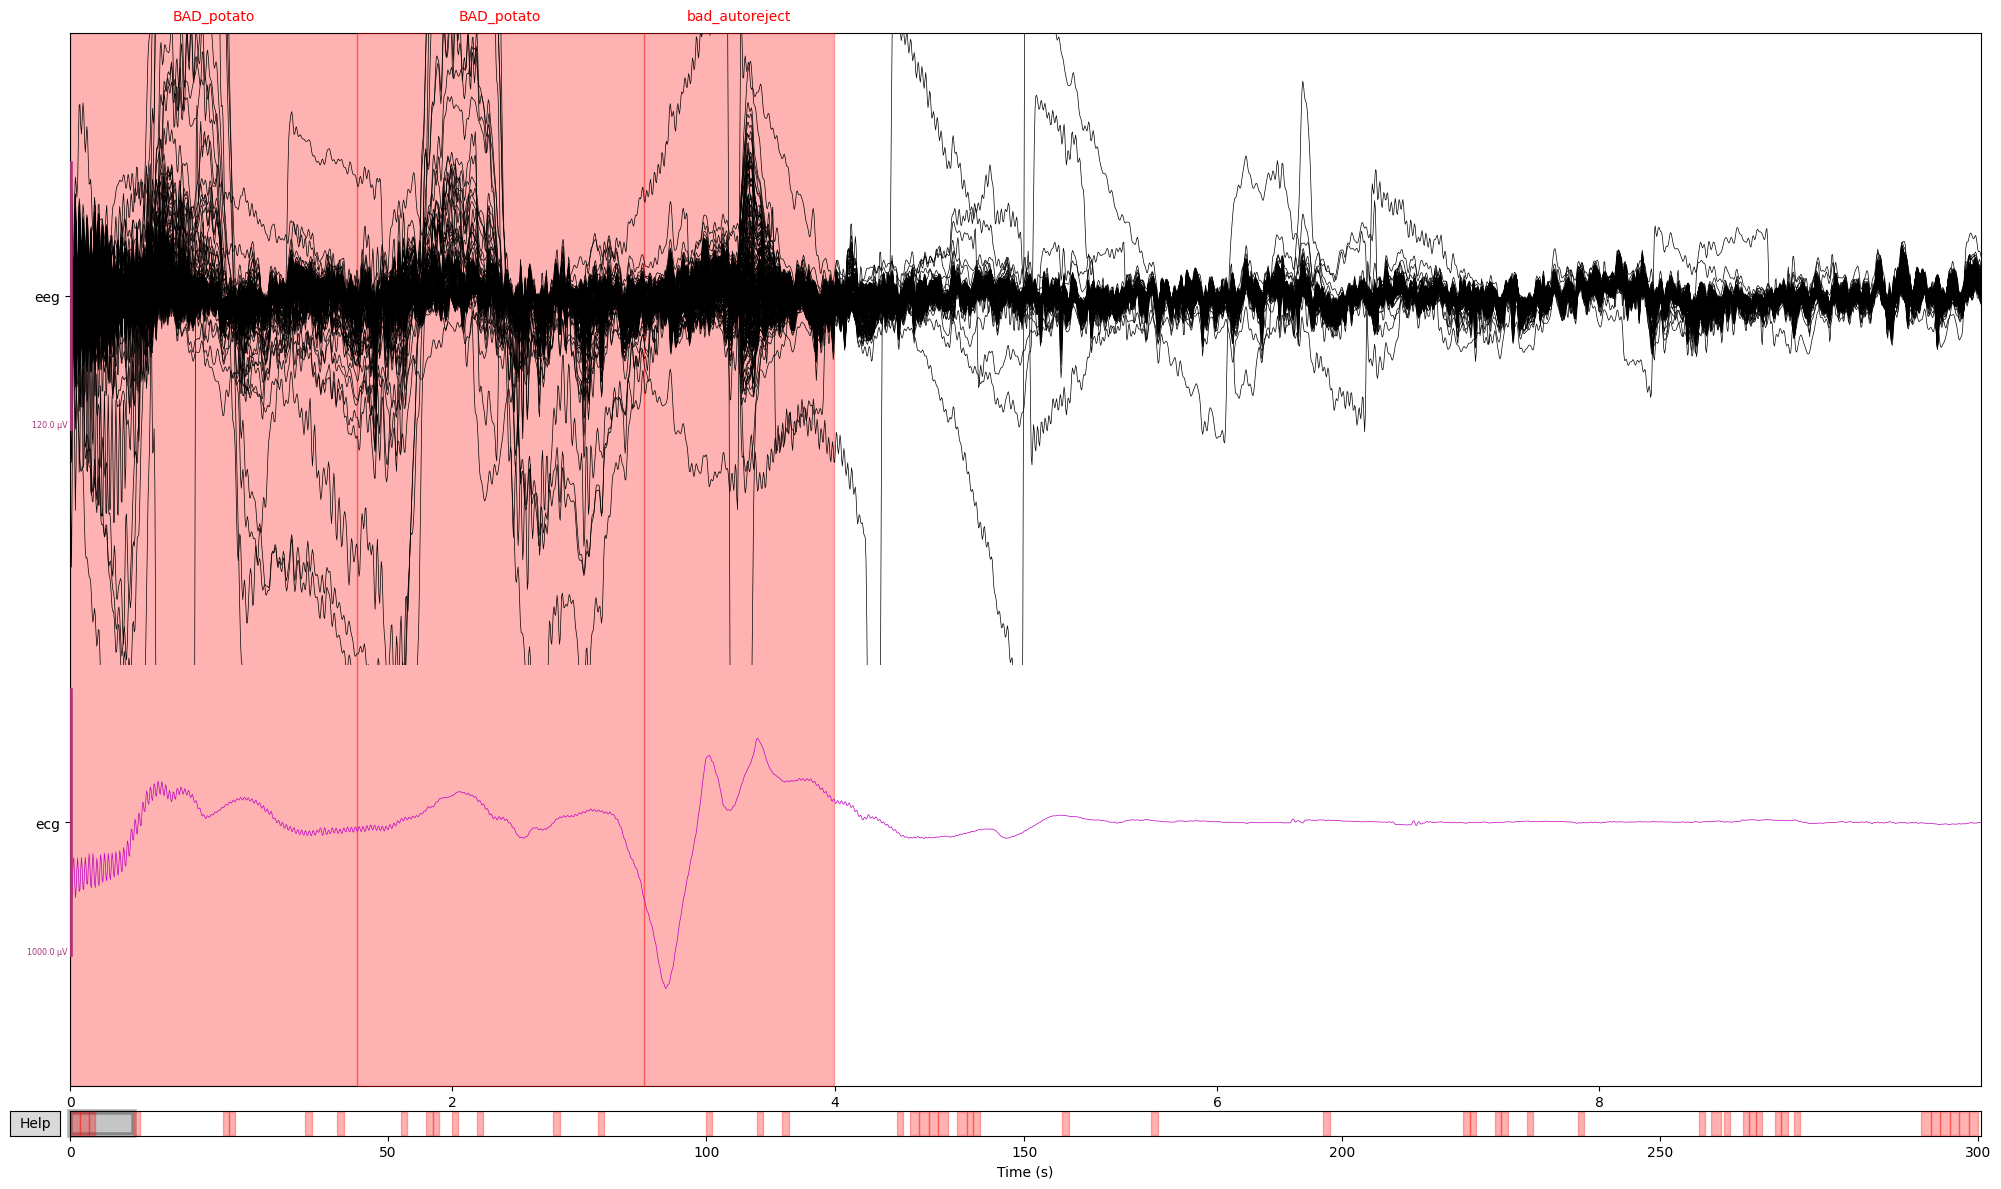

In [20]:
raw_final = raw.copy()
raw_final.set_annotations(raw_final.annotations + raw_annotated_final.annotations)

# 2. Sync the bad channels list
# This ensures 'HF Noise' or 'Threshold' channels are marked in the original file
raw_final.info["bads"] = raw_annotated_final.info["bads"]

print(f"Annotations: {len(raw.annotations)}")
print(f"Bad Channels: {raw.info['bads']}")

fline = [50, 100]  # Line noise frequencies
h_freq = 45
l_freq = 1


filter_params = {
    "l_freq": l_freq,
    "h_freq": h_freq,
    "h_trans_bandwidth": "auto",
    "fir_window": "hamming",
    "fir_design": "firwin",
    "phase": "zero",
    "picks": ["ecg", "eeg"],
}

standard_scalings = {
    "eeg": 60e-6,  # 40 µV (Good for clean brainwaves)
    "ecg": 500e-6,  # 500 µV (ECG is naturally much larger)
    "eog": 150e-6,
}
raw_final_filtered = (
    raw_final.copy()
    .resample(250, method="polyphase", verbose=True)
    .drop_channels(bad_channels)
    .notch_filter(freqs=[fline], method="fir", picks=["eeg", "ecg"])
    .filter(**filter_params)
    # .crop(tmin=3.0, tmax=total_duration - 3, include_tmax=True)
)
raw_final_filtered.plot(scalings=standard_scalings, butterfly=True)

In [12]:
sensor_plot = raw_final_filtered.plot_sensors(show_names=True)

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))
raw_psd = (
    raw_final_filtered.copy()
    .crop(tmin=3.0, tmax=total_duration - 3, include_tmax=True)
    .compute_psd(fmax=60.0, method="welch", picks="eeg", exclude="bads")
    .plot(
        average=False, picks="eeg", exclude="bads", show=False, axes=ax, amplitude=False
    )
)
ax.set_title(f"sub-{subject_id} PSD")

Setting 12814 of 73600 (17.41%) samples to NaN, retaining 60786 (82.59%) samples.
Effective window size : 8.192 (s)
At least one good data span is shorter than n_per_seg, and will be analyzed with a shorter window than the rest of the file.
Plotting power spectral density (dB=True).


/Users/daniel/PhD/Projects/psd-paths/.venv/lib/python3.13/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 1501, using nperseg = 1501
  return _func(*args, **kwargs)
/Users/daniel/PhD/Projects/psd-paths/.venv/lib/python3.13/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 1, using nperseg = 1
  return _func(*args, **kwargs)
/Users/daniel/PhD/Projects/psd-paths/.venv/lib/python3.13/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 1001, using nperseg = 1001
  return _func(*args, **kwargs)
/Users/daniel/PhD/Projects/psd-paths/.venv/lib/python3.13/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 751, using nperseg = 751
  return _func(*args, **kwargs)
/Users/daniel/PhD/Projects/psd-paths/.venv/lib/python3.13/site-packages/mne/time_frequency/psd.py:291: UserWarning: nper

Text(0.5, 1.0, 'sub-101 PSD')

In [41]:
from spectral.ica import compute_ica

raw_filtered_ica = raw_final_filtered.copy().filter(l_freq=1.0, h_freq=None)
ica = compute_ica(raw_filtered_ica, n_components=40, method="picard")


print(ica.n_components_)
if ica.n_components_ > 50:
    ica = compute_ica(epochs_good, n_components=50, method="picard")
ica.save(f"{paths.ica}/sub-{subject_id}_my_ica_model-ica.fif", overwrite=True)
ica_plot_components = ica.plot_components()
ica_plot = ica.plot_sources(raw_filtered_ica, show_scrollbars=True)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Fitting ICA to data using 243 channels (please be patient, this may take a while)
Omitting 14214 of 75100 (18.93%) samples, retaining 60886 (81.07%) samples.
Selecting by number: 40 components


/Users/daniel/PhD/Projects/psd-paths/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2374: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


FloatingPointError: overflow encountered in slogdet

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
raw_psd = (
    raw_filtered.copy()
    .crop(tmin=3.0, tmax=total_duration - 3, include_tmax=True)
    .compute_psd(fmax=60.0, method="welch", picks="eeg", exclude="bads")
    .plot(
        average=False, picks="eeg", exclude="bads", show=False, axes=ax, amplitude=False
    )
)
ax.set_title(f"sub-{subject_id} PSD")

## Filter characteristic

In [14]:
from mne.viz import plot_filter, plot_ideal_filter
from scipy import signal

sfreq = 1000.0
f_p = 45.0
nyq = sfreq / 2.0  # the Nyquist frequency is half our sample rate
freq = [0, f_p, f_p, nyq]
gain = [1, 1, 0, 0]
flim = (1.0, sfreq / 2.0)  # frequencies
dlim = (-0.2, 0.2)  # delays
duration = 1.0  # duration in seconds
kwargs = dict(flim=flim, dlim=dlim)

x = np.zeros(int(sfreq * duration) + 1)
iir_params = dict(order=8, ftype="butter")
filt = mne.filter.create_filter(
    x, sfreq, l_freq=None, h_freq=f_p, method="iir", iir_params=iir_params, verbose=True
)
plot_filter(filt, sfreq, freq, gain, "Butterworth order=8", compensate=True, **kwargs)
x_steep = signal.sosfiltfilt(filt["sos"], x)

Setting up low-pass filter at 45 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoff at 45.00 Hz: -6.02 dB

